In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from typing import Dict

from hyperspace.backends import HRRBackend
from hyperspace.core import (
    CleanupModule,
    MemoryStorageModule,
    PositionalEncoderModule,
    PositionalInversionModule,
    RegressionModule,
    ValueEncoderModule
)

In [2]:
EXP_CONFIG: Dict = {
    "num_training_points": 20,
    "num_gt_points": 100,
    "seed": 42,
    "x_dim_min": 0,
    "x_dim_max": 2 * np.pi,
}

VSA_CONFIG: Dict = {
    "vector_dim": 256,
    "vector_length_scale": 1,
    "device": "cpu"
}

In [3]:
# -----------------
# Generate GT Data
# -----------------
x_gt: np.ndarray = np.linspace(
    EXP_CONFIG["x_dim_min"],
    EXP_CONFIG["x_dim_max"],
    EXP_CONFIG["num_gt_points"]
)
y_gt: np.ndarray = np.sin(x_gt)

# normalize both axes to between [0, 1]
x_gt_norm = x_gt / EXP_CONFIG["x_dim_max"]
y_gt_norm = y_gt + 1
y_gt_norm /= 2

# updating types and shapes to conform to hyperspace's API

x_gt_norm: torch.Tensor = torch.from_numpy(x_gt_norm)
y_gt_norm: torch.Tensor = torch.from_numpy(y_gt_norm)

x_gt_norm = x_gt_norm.unsqueeze(-1)
y_gt_norm = y_gt_norm.unsqueeze(-1)

print(f"x_gt_norm type: {type(x_gt_norm)}; shape: {x_gt_norm.shape}")
print(f"y_gt_norm type: {type(y_gt_norm)}; shape: {y_gt_norm.shape}")

assert isinstance(x_gt_norm, torch.Tensor)
assert isinstance(y_gt_norm, torch.Tensor)
assert x_gt_norm.shape == (EXP_CONFIG["num_gt_points"], 1)
assert y_gt_norm.shape == (EXP_CONFIG["num_gt_points"], 1)

x_gt_norm type: <class 'torch.Tensor'>; shape: torch.Size([100, 1])
y_gt_norm type: <class 'torch.Tensor'>; shape: torch.Size([100, 1])


In [4]:
# ----------------------
# Generate Sampled Data
# ----------------------
x_Train: np.ndarray = np.linspace(
    EXP_CONFIG["x_dim_min"],
    EXP_CONFIG["x_dim_max"],
    EXP_CONFIG["num_training_points"]
)
y_Train: np.ndarray = np.sin(x_Train)

# normalize both axes to between [0, 1]
x_Train_norm: np.ndarray = x_Train / EXP_CONFIG["x_dim_max"]
y_Train_norm: np.ndarray = y_Train + 1
y_Train_norm /= 2

assert isinstance(x_Train_norm, np.ndarray)
assert isinstance(y_Train_norm, np.ndarray)
assert x_Train_norm.shape == (EXP_CONFIG["num_training_points"],)
assert y_Train_norm.shape == (EXP_CONFIG["num_training_points"],)

# updating types and shapes to conform to hyperspace's API

x_Train_norm: torch.Tensor = torch.from_numpy(x_Train_norm)
y_Train_norm: torch.Tensor = torch.from_numpy(y_Train_norm)

x_Train_norm = x_Train_norm.unsqueeze(-1)
y_Train_norm = y_Train_norm.unsqueeze(-1)

print(f"x_Train_norm type: {type(x_Train_norm)}; shape: {x_Train_norm.shape}")
print(f"y_Train_norm type: {type(y_Train_norm)}; shape: {y_Train_norm.shape}")

assert isinstance(x_Train_norm, torch.Tensor)
assert isinstance(y_Train_norm, torch.Tensor)
assert x_Train_norm.shape == (EXP_CONFIG["num_training_points"], 1)
assert y_Train_norm.shape == (EXP_CONFIG["num_training_points"], 1)

x_Train_norm type: <class 'torch.Tensor'>; shape: torch.Size([20, 1])
y_Train_norm type: <class 'torch.Tensor'>; shape: torch.Size([20, 1])


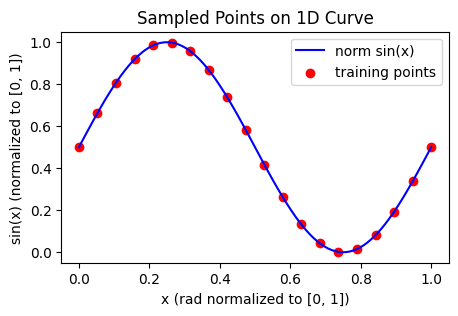

In [5]:
plt.figure(figsize=(5, 3))
plt.plot(x_gt_norm, y_gt_norm, label="norm sin(x)", color="blue")
plt.scatter(x_Train_norm, y_Train_norm, label="training points", color="red")
plt.title("Sampled Points on 1D Curve")
plt.xlabel("x (rad normalized to [0, 1])")
plt.ylabel("sin(x) (normalized to [0, 1])")
plt.legend()
plt.show()

In [6]:
# ------------------------------
# Initialize HyperSpace Modules
# ------------------------------
hrr_backend = HRRBackend(
    vector_dim=VSA_CONFIG["vector_dim"],
    length_scale=VSA_CONFIG["vector_length_scale"],
    device=VSA_CONFIG["device"]
)

In [9]:
# -----------------------------------------------------------------
# Encode the ground truth and sampling positions into vector space
# -----------------------------------------------------------------
x_gt_vectors, _ = hrr_backend.positional_encoding(x_gt_norm)
x_Train_vectors, _ = hrr_backend.positional_encoding(x_Train_norm)

print(f"x_gt_vectors type: {type(x_gt_vectors)}; shape: {x_gt_vectors.shape}")
print(f"x_Train_vectors type: {type(x_Train_vectors)}; shape: {x_Train_vectors.shape}")

assert isinstance(x_gt_vectors, torch.Tensor)
assert isinstance(x_Train_vectors, torch.Tensor)
assert x_gt_vectors.shape == (
    EXP_CONFIG["num_gt_points"],
    VSA_CONFIG["vector_dim"]
)
assert x_Train_vectors.shape == (
    EXP_CONFIG["num_training_points"],
    VSA_CONFIG["vector_dim"]
)

sims, _ = hrr_backend.similarity(x_gt_vectors, x_Train_vectors)

print(sims.shape)

x_gt_vectors type: <class 'torch.Tensor'>; shape: torch.Size([100, 256])
x_Train_vectors type: <class 'torch.Tensor'>; shape: torch.Size([20, 256])
torch.Size([100, 20])
